# Cuaderno 05 · Resultados potenciales y el experimento NSW

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 5 de 10 · **Inicio de la Sección 2 (causalidad)**

> Cuaderno reproducible asociado al artículo divulgativo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

La Sección 1 mostró que la explicabilidad describe el modelo, no el mundo, y que para afirmar algo causal hace falta un lenguaje formal. Ese lenguaje es el **marco de resultados potenciales** (Neyman, 1923; Rubin, 1974), que aquí se desarrolla con definiciones, proposiciones y demostraciones, y se pone a prueba sobre un experimento real: el **National Supported Work** (NSW). El cuaderno cierra con el **desafío de LaLonde (1986)** —reemplazar el grupo de control aleatorizado por uno observacional—, que hace colapsar la estimación ingenua y motiva todo lo que sigue: qué supuestos y qué ajustes permiten estimar efectos sin un experimento.

## Contenido y objetivos

1. **Marco de resultados potenciales** — resultados potenciales, efecto individual, estimandos (ATE, ATT, ATC), SUTVA y la descomposición de la diferencia ingenua (con demostración).
2. **Identificación por aleatorización** — ignorabilidad, positividad y la proposición que justifica la diferencia de medias (con demostración).
3. **El experimento NSW** — estimación del ATE con su intervalo y verificación del **balance** de covariables.
4. **El desafío de LaLonde** — experimental vs. observacional (CPS/PSID): el sesgo de selección, el balance roto y el alcance limitado del ajuste por regresión.

**Objetivos.** (i) Definir con precisión el efecto causal y sus estimandos; (ii) **demostrar** cuándo la diferencia de medias identifica el ATE; (iii) estimar y validar el efecto en un experimento real; (iv) constatar el colapso de la estimación ingenua en datos observacionales y nombrar su causa (la confusión).

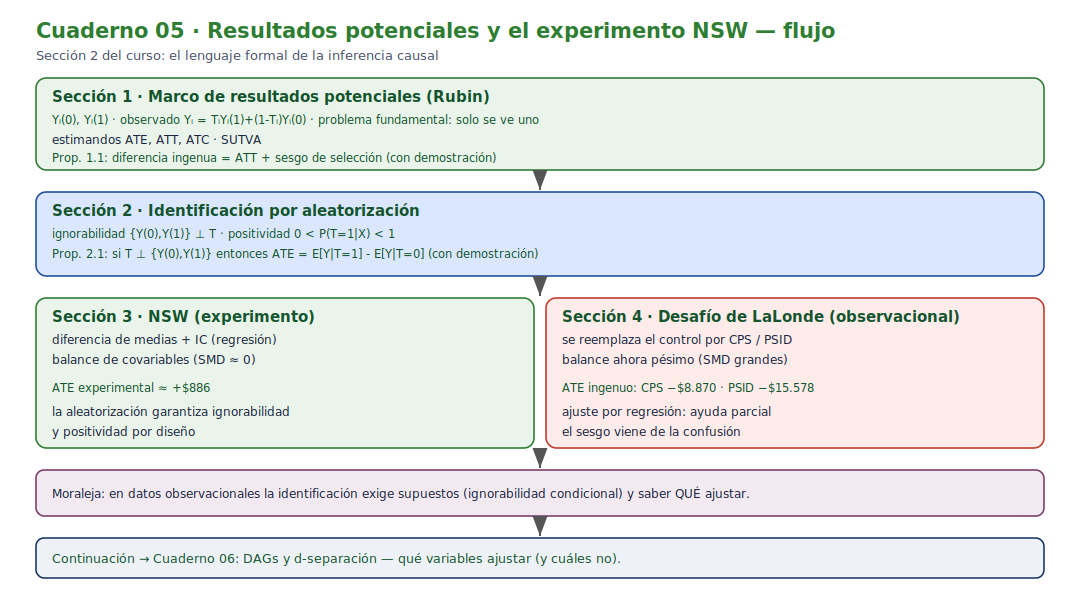

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/05_flujo.svg')
if not _svg.exists():
    _svg = Path('img/05_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Configuración y datos
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_nsw, load_lalonde_obs

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE); np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})

exp = load_nsw()                       # experimento NSW (297 tratados + 425 controles)
covs = ["edad", "educacion", "afroamericano", "hispano", "casado", "sin_grado", "re75"]
print("NSW experimental:", exp.shape, "| tratados:", int(exp.tratamiento.sum()),
      "| controles:", int((exp.tratamiento == 0).sum()))

NSW experimental: (722, 9) | tratados: 297 | controles: 425


## Sección 1 · El marco de resultados potenciales

La pregunta causal "¿cuál es el efecto del programa de empleo sobre los ingresos?" se formaliza imaginando, para cada persona, **dos mundos**: uno en que recibe el tratamiento y otro en que no.

> **Definición 1.1 (resultados potenciales).** Para un tratamiento binario $T\in\{0,1\}$, cada unidad $i$ posee dos *resultados potenciales*: $Y_i(1)$ (su resultado si recibe el tratamiento) e $Y_i(0)$ (si no lo recibe). El resultado **observado** es el correspondiente al tratamiento efectivamente recibido,
> $$ Y_i = T_i\,Y_i(1) + (1-T_i)\,Y_i(0). $$

> **Definición 1.2 (efecto individual del tratamiento).** $\tau_i = Y_i(1)-Y_i(0)$.

> **Observación 1.1 (problema fundamental de la inferencia causal).** Para cada unidad se observa **uno solo** de los dos resultados potenciales; el otro es contrafactual. Por tanto $\tau_i$ **nunca es observable** a nivel individual (Holland, 1986). La inferencia causal estima *promedios* de $\tau_i$, no sus valores individuales.

> **Definición 1.3 (estimandos promedio).**
> $$ \mathrm{ATE}=\mathbb E[\tau]=\mathbb E[Y(1)-Y(0)],\quad \mathrm{ATT}=\mathbb E[\tau\mid T{=}1],\quad \mathrm{ATC}=\mathbb E[\tau\mid T{=}0]. $$
> El **ATE** es el efecto promedio en toda la población; el **ATT**, el efecto sobre los que de hecho se trataron (a menudo el de interés en política pública).

> **Definición 1.4 (SUTVA).** El *Stable Unit Treatment Value Assumption* exige (i) **no interferencia**: el resultado de una unidad no depende del tratamiento de las demás; y (ii) **consistencia**: hay una sola versión de cada tratamiento, de modo que $Y_i=Y_i(T_i)$ está bien definido. Sin SUTVA, los resultados potenciales ni siquiera están bien planteados.

La cantidad que se calcula de inmediato con los datos es la **diferencia de medias** entre tratados y controles. ¿Qué estima? No el ATE, en general.

> **Proposición 1.1 (descomposición de la diferencia ingenua).**
> $$ \underbrace{\mathbb E[Y\mid T{=}1]-\mathbb E[Y\mid T{=}0]}_{\text{diferencia observada}}=\underbrace{\mathrm{ATT}}_{\mathbb E[Y(1)-Y(0)\mid T{=}1]}+\underbrace{\mathbb E[Y(0)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]}_{\text{sesgo de selección}}. $$
>
> **Demostración.** Por consistencia (SUTVA), $\mathbb E[Y\mid T{=}1]=\mathbb E[Y(1)\mid T{=}1]$ y $\mathbb E[Y\mid T{=}0]=\mathbb E[Y(0)\mid T{=}0]$. Restando y sumando el término $\mathbb E[Y(0)\mid T{=}1]$:
> $$ \mathbb E[Y(1)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]=\underbrace{\big(\mathbb E[Y(1)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}1]\big)}_{\mathrm{ATT}}+\underbrace{\big(\mathbb E[Y(0)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]\big)}_{\text{sesgo de selección}}. $$
> $\blacksquare$
>
> **Observación 1.2.** El **sesgo de selección** compara el resultado *sin tratamiento* de tratados y controles: mide cuán **distintos de base** son los dos grupos. Si quienes se tratan habrían tenido peores (o mejores) ingresos de todos modos, la diferencia observada no es el efecto causal. Anular ese término es el problema central.

### Ejemplo guía: la "tabla de ciencia"

Para volver tangibles las Definiciones 1.1–1.3 y la Proposición 1.1, imaginemos una población de **seis** individuos de los que, *idealmente*, conociéramos **ambos** resultados potenciales —la "tabla de ciencia" de Imbens & Rubin (2015)—. En la práctica cada individuo solo revela el resultado de su tratamiento recibido (`Y_obs`); el otro (`Y_contraf`) queda **oculto** (el problema fundamental, Observación 1.1). Supondremos además que se tratan los individuos de **menor ingreso de base** $Y(0)$, una selección realista en programas sociales.

In [3]:
# Tabla de ciencia: 6 individuos con AMBOS resultados potenciales (ideal)
ciencia = pd.DataFrame({"Y0": [5, 6, 4, 9, 8, 10],
                        "Y1": [8, 8, 9, 11, 10, 12]})
ciencia["tau"] = ciencia["Y1"] - ciencia["Y0"]          # efecto individual (Def. 1.2)
ciencia["trat"] = [1, 1, 1, 0, 0, 0]                    # se tratan los de menor Y(0)
ciencia["Y_obs"] = np.where(ciencia["trat"] == 1, ciencia["Y1"], ciencia["Y0"])
ciencia["Y_contraf"] = np.where(ciencia["trat"] == 1, ciencia["Y0"], ciencia["Y1"])
ciencia.index = [f"i{j}" for j in range(1, 7)]
print("Tabla de ciencia (en la práctica, Y_contraf está OCULTO):")
print(ciencia.to_string(), "\n")

ATE = ciencia["tau"].mean()
ATT = ciencia.loc[ciencia["trat"] == 1, "tau"].mean()
naive = (ciencia.loc[ciencia["trat"] == 1, "Y_obs"].mean()
         - ciencia.loc[ciencia["trat"] == 0, "Y_obs"].mean())
sesgo = (ciencia.loc[ciencia["trat"] == 1, "Y0"].mean()
         - ciencia.loc[ciencia["trat"] == 0, "Y0"].mean())
print(f"ATE = E[tau]               = {ATE:+.2f}")
print(f"ATT = E[tau | trat=1]      = {ATT:+.2f}")
print(f"diferencia ingenua         = {naive:+.2f}")
print(f"sesgo de selección         = {sesgo:+.2f}")
print(f"ATT + sesgo de selección   = {ATT + sesgo:+.2f}   (= diferencia ingenua -> Proposición 1.1)")

Tabla de ciencia (en la práctica, Y_contraf está OCULTO):
    Y0  Y1  tau  trat  Y_obs  Y_contraf
i1   5   8    3     1      8          5
i2   6   8    2     1      8          6
i3   4   9    5     1      9          4
i4   9  11    2     0      9         11
i5   8  10    2     0      8         10
i6  10  12    2     0     10         12 

ATE = E[tau]               = +2.67
ATT = E[tau | trat=1]      = +3.33
diferencia ingenua         = -0.67
sesgo de selección         = -4.00
ATT + sesgo de selección   = -0.67   (= diferencia ingenua -> Proposición 1.1)


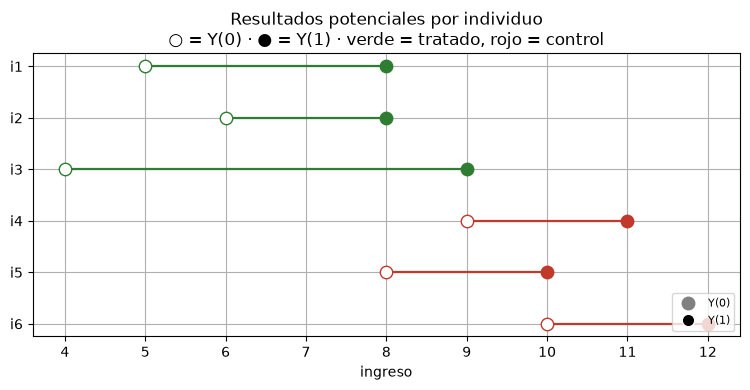

In [4]:
# Figura · resultados potenciales por individuo (se ve el efecto y la selección)
fig, ax = plt.subplots(figsize=(7.6, 4))
for k, (idx, r) in enumerate(ciencia.iterrows()):
    c = "#2e7d32" if r["trat"] == 1 else "#c0392b"
    ax.plot([r["Y0"], r["Y1"]], [k, k], color=c, lw=1.6, zorder=1)
    ax.scatter(r["Y0"], k, facecolor="white", edgecolor=c, s=80, zorder=3)   # Y(0)
    ax.scatter(r["Y1"], k, color=c, s=80, zorder=3)                          # Y(1)
ax.set_yticks(range(6)); ax.set_yticklabels(ciencia.index); ax.invert_yaxis()
ax.set_xlabel("ingreso"); ax.set_title("Resultados potenciales por individuo\n"
              "○ = Y(0) · ● = Y(1) · verde = tratado, rojo = control")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor='gray',markeredgecolor='gray',label='Y(0)',markersize=9),
                   Line2D([0],[0],marker='o',color='w',markerfacecolor='black',label='Y(1)',markersize=9)],
          fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

**Lectura del ejemplo.** El efecto causal es **positivo** para todos ($\tau_i>0$): el ATE es $+2.67$ y el ATT $+3.33$. Y, sin embargo, la **diferencia ingenua es negativa** ($-0.67$): parecería que el programa *reduce* el ingreso. La culpa es el **sesgo de selección** ($-4$): los tratados partían de un $Y(0)$ mucho menor (promedio $5$ frente a $9$ en los controles), como se ve en la figura —los círculos verdes (tratados) están a la izquierda—. La identidad $\mathrm{ATT}+\text{sesgo}=3.33+(-4)=-0.67$ confirma numéricamente la **Proposición 1.1**.

Este ejemplo reproduce en miniatura lo que ocurrió con los controles observacionales **CPS/PSID** de la Sección 4: un efecto real positivo enmascarado por un sesgo de selección negativo. La **aleatorización** (Proposición 2.1) lo evita porque iguala el $Y(0)$ promedio de ambos grupos, anulando ese término.

## Sección 2 · Identificación por aleatorización

¿Cuándo la diferencia de medias **sí** estima el ATE? Cuando el mecanismo de asignación es independiente de los resultados potenciales.

> **Definición 2.1 (ignorabilidad o no confusión).** El tratamiento es *ignorable* si $\{Y(0),Y(1)\}\perp T$. Versión condicional (datos observacionales): $\{Y(0),Y(1)\}\perp T\mid X$ —dado un conjunto de covariables $X$, el tratamiento es "como aleatorio"—.

> **Definición 2.2 (positividad o solapamiento).** $0<P(T{=}1\mid X{=}x)<1$ para todo $x$ con densidad positiva: ambos tratamientos son posibles en cada estrato de $X$. Sin positividad no hay con qué comparar.

> **Proposición 2.1 (identificación bajo aleatorización).** Si $\{Y(0),Y(1)\}\perp T$ (como en un experimento aleatorizado), entonces para $t\in\{0,1\}$
> $$ \mathbb E[Y(t)]=\mathbb E[Y\mid T{=}t], \qquad\text{y por tanto}\qquad \mathrm{ATE}=\mathbb E[Y\mid T{=}1]-\mathbb E[Y\mid T{=}0]. $$
>
> **Demostración.** Por consistencia, $\mathbb E[Y\mid T{=}t]=\mathbb E[Y(t)\mid T{=}t]$. Por ignorabilidad, $Y(t)\perp T$, de modo que condicionar en $T{=}t$ no cambia la media: $\mathbb E[Y(t)\mid T{=}t]=\mathbb E[Y(t)]$. Encadenando, $\mathbb E[Y\mid T{=}t]=\mathbb E[Y(t)]$. Restando los casos $t{=}1$ y $t{=}0$ se obtiene $\mathbb E[Y\mid T{=}1]-\mathbb E[Y\mid T{=}0]=\mathbb E[Y(1)]-\mathbb E[Y(0)]=\mathrm{ATE}$. $\blacksquare$
>
> **Observación 2.1.** La aleatorización **garantiza** la ignorabilidad y la positividad **por diseño**: anula el sesgo de selección de la Proposición 1.1 (los grupos son intercambiables de base) e implica además $\mathrm{ATE}=\mathrm{ATT}$. En datos observacionales, en cambio, la ignorabilidad condicional es un **supuesto no verificable**; toda la Sección 2 del curso trata de cómo hacerlo plausible.

## Sección 3 · El experimento NSW

El **National Supported Work Demonstration** (1976–1977) asignó *al azar* a participantes desfavorecidos a un programa de empleo subsidiado. El resultado es el ingreso real de 1978 (`re78`). Por la Proposición 2.1, el ATE se estima con la diferencia de medias; añadimos su **intervalo de confianza** mediante una regresión de `re78` sobre el tratamiento.

In [5]:
# Estimación del ATE experimental (diferencia de medias = pendiente de la regresión)
m_exp = smf.ols("re78 ~ tratamiento", data=exp).fit()
ate_exp = m_exp.params["tratamiento"]
ic = m_exp.conf_int().loc["tratamiento"]
print(f"ATE experimental (NSW)   = {ate_exp:8.1f} USD")
print(f"IC 95%                   = [{ic[0]:.1f}, {ic[1]:.1f}]")
print(f"error estándar / p-valor = {m_exp.bse['tratamiento']:.1f} / {m_exp.pvalues['tratamiento']:.3f}")

ATE experimental (NSW)   =    886.3 USD
IC 95%                   = [-40.5, 1813.1]
error estándar / p-valor = 472.1 / 0.061


La aleatorización debe producir grupos **balanceados**: covariables con medias semejantes en tratados y controles. Se mide con la **diferencia de medias estandarizada** (SMD),
$$ \mathrm{SMD}_v=\frac{\bar v_{T=1}-\bar v_{T=0}}{\sqrt{(s^2_{v,T=1}+s^2_{v,T=0})/2}}, $$
que por convención se considera aceptable si $|\mathrm{SMD}|<0.1$.

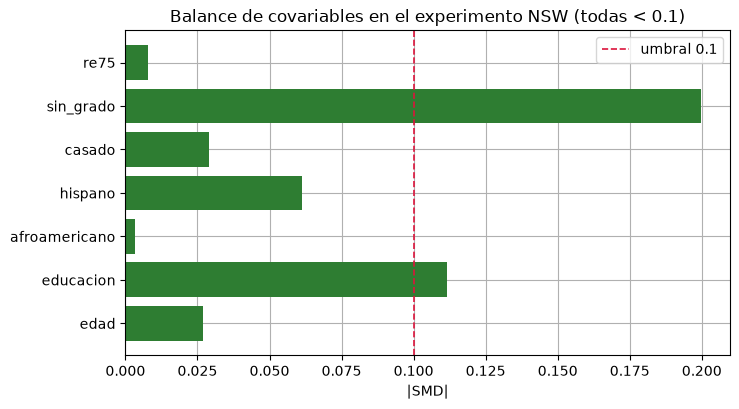

edad             0.027
educacion        0.112
afroamericano    0.003
hispano         -0.061
casado           0.029
sin_grado       -0.200
re75             0.008


In [6]:
# Balance de covariables en el experimento (SMD)
def smd(df, covs):
    t = df[df.tratamiento == 1]; c = df[df.tratamiento == 0]
    return pd.Series({v: (t[v].mean() - c[v].mean()) /
                      np.sqrt((t[v].var() + c[v].var()) / 2) for v in covs})

smd_exp = smd(exp, covs)
plt.figure(figsize=(7.5, 4.2))
plt.barh(covs, smd_exp.abs().values, color="#2e7d32")
plt.axvline(0.1, color="crimson", ls="--", lw=1.2, label="umbral 0.1")
plt.xlabel("|SMD|"); plt.title("Balance de covariables en el experimento NSW (todas < 0.1)")
plt.legend(); plt.tight_layout(); plt.show()
print(smd_exp.round(3).to_string())

Todas las covariables tienen $|\mathrm{SMD}|<0.1$: la aleatorización funcionó. En consecuencia, los \$886 estimados **son** el efecto causal del programa, sin necesidad de ajuste alguno.

## Sección 4 · El desafío de LaLonde: experimental vs. observacional

LaLonde (1986) planteó una prueba devastadora: **descartar el grupo de control aleatorizado** y reemplazarlo por una muestra observacional de la población general (la encuesta **CPS** o **PSID**). Si los métodos no experimentales fueran fiables, deberían recuperar los \$886. No lo hacen.

In [7]:
# Estimación ingenua con grupos de control observacionales
cps = load_lalonde_obs("cps")
psid = load_lalonde_obs("psid")
def dif_medias(df):
    return df.loc[df.tratamiento == 1, "re78"].mean() - df.loc[df.tratamiento == 0, "re78"].mean()
ate_cps, ate_psid = dif_medias(cps), dif_medias(psid)
print(f"ATE experimental (NSW)        = {ate_exp:9.1f} USD   (referencia)")
print(f"ATE ingenuo · control CPS     = {ate_cps:9.1f} USD")
print(f"ATE ingenuo · control PSID    = {ate_psid:9.1f} USD")

ATE experimental (NSW)        =     886.3 USD   (referencia)


ATE ingenuo · control CPS     =   -8870.3 USD
ATE ingenuo · control PSID    =  -15577.6 USD


La estimación ingenua no solo se aleja: **cambia de signo** (de $+\$886$ a $-\$8.870$ con CPS, $-\$15.578$ con PSID). Según la Proposición 1.1, esto es **sesgo de selección**: los controles observacionales son personas con ingresos de base mucho mayores que los participantes. Lo confirma el balance.

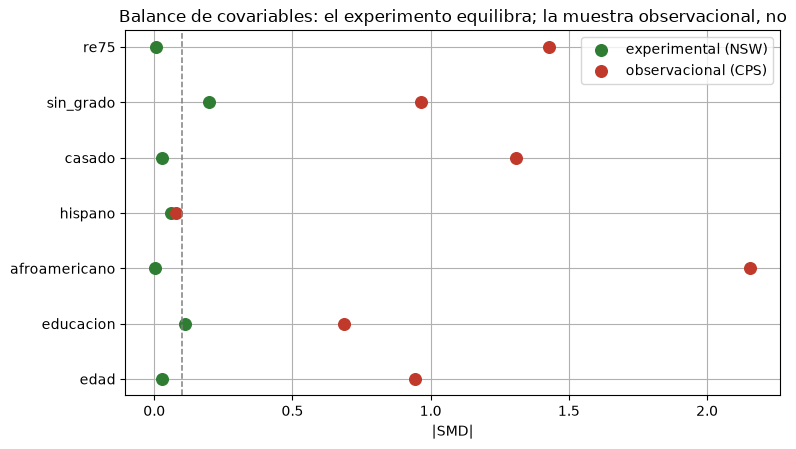

SMD CPS:
 edad            -0.94
educacion       -0.69
afroamericano    2.16
hispano          0.08
casado          -1.31
sin_grado        0.97
re75            -1.43


In [8]:
# Balance roto: experimento vs. CPS
smd_cps = smd(cps, covs)
ypos = np.arange(len(covs))
plt.figure(figsize=(8, 4.6))
plt.scatter(smd_exp.abs().values, ypos, s=70, color="#2e7d32", label="experimental (NSW)")
plt.scatter(smd_cps.abs().values, ypos, s=70, color="#c0392b", label="observacional (CPS)")
plt.axvline(0.1, color="gray", ls="--", lw=1.1)
plt.yticks(ypos, covs); plt.xlabel("|SMD|")
plt.title("Balance de covariables: el experimento equilibra; la muestra observacional, no")
plt.legend(); plt.tight_layout(); plt.show()
print("SMD CPS:\n", smd_cps.round(2).to_string())

¿Y si **ajustamos** por las covariables con una regresión? Ayuda, pero no basta: el ajuste lineal corrige parte del sesgo, sin recuperar el valor experimental, porque depende de supuestos (forma funcional correcta, ausencia de confusores no medidos) que aquí no se cumplen del todo.

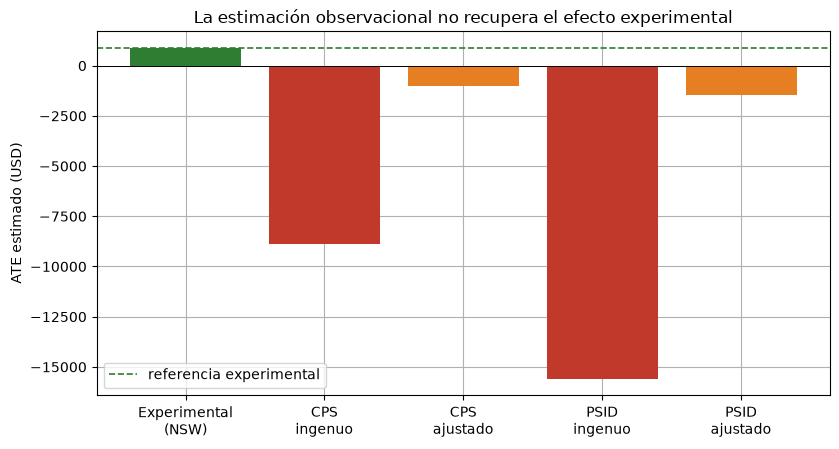

  Experimental (NSW)       =     886.3 USD
  CPS ingenuo              =   -8870.3 USD
  CPS ajustado             =    -992.9 USD
  PSID ingenuo             =  -15577.6 USD
  PSID ajustado            =   -1457.9 USD


In [9]:
# Ajuste por regresión en la muestra observacional (CPS)
f_adj = ("re78 ~ tratamiento + edad + educacion + afroamericano + hispano "
         "+ casado + sin_grado + re75")
ate_cps_adj = smf.ols(f_adj, data=cps).fit().params["tratamiento"]
ate_psid_adj = smf.ols(f_adj, data=psid).fit().params["tratamiento"]

estim = {"Experimental\n(NSW)": ate_exp, "CPS\ningenuo": ate_cps,
         "CPS\najustado": ate_cps_adj, "PSID\ningenuo": ate_psid,
         "PSID\najustado": ate_psid_adj}
colores = ["#2e7d32", "#c0392b", "#e67e22", "#c0392b", "#e67e22"]
plt.figure(figsize=(8.5, 4.6))
plt.bar(list(estim), list(estim.values()), color=colores)
plt.axhline(ate_exp, color="#2e7d32", ls="--", lw=1.2, label="referencia experimental")
plt.axhline(0, color="k", lw=.7)
plt.ylabel("ATE estimado (USD)"); plt.title("La estimación observacional no recupera el efecto experimental")
plt.legend(); plt.tight_layout(); plt.show()
for k, v in estim.items():
    print(f"  {k.replace(chr(10),' '):24s} = {v:9.1f} USD")

**Observación 4.1.** El ajuste por regresión acerca la estimación, pero no la iguala: corregir el sesgo de selección requiere (i) **identificar los confusores correctos** —no cualquier covariable sirve, y algunas *no* deben incluirse (cuaderno 06)— y (ii) **estimadores adecuados** —emparejamiento, ponderación, *doubly robust*— (cuadernos 07–08). El experimento sirve aquí de **patrón de oro** para juzgarlos.

## Síntesis

- El efecto causal se define sobre **resultados potenciales** $Y(0),Y(1)$; solo se observa uno (problema fundamental), así que se estiman promedios (ATE, ATT, ATC) bajo **SUTVA**.
- La diferencia de medias = ATT + **sesgo de selección** (Proposición 1.1). La **aleatorización** anula ese sesgo y hace $\mathrm{ATE}=\mathbb E[Y\mid T{=}1]-\mathbb E[Y\mid T{=}0]$ (Proposición 2.1): en NSW, $+\$886$ con buen balance.
- Al reemplazar el control aleatorizado por uno observacional (CPS/PSID), la estimación ingenua se vuelve **fuertemente negativa**: puro sesgo de selección, visible en el balance roto. El ajuste por regresión ayuda pero no basta.
- **Conclusión.** Sin experimento, identificar el efecto exige supuestos (ignorabilidad condicional, positividad) y decidir **qué** ajustar. El cuaderno 06 da el lenguaje para ello: los **DAGs** y la d-separación.

## Ejemplos complementarios

Cinco ejemplos desarrollados sobre el experimento y el contraste observacional.

### Ejemplo 1 · ATE y ATT coinciden bajo aleatorización

La Proposición 2.1 implica $\mathrm{ATE}=\mathrm{ATT}$ en un experimento. Se estima el ATT como diferencia de medias restringida y se compara con el ATE.

In [10]:
att = exp.loc[exp.tratamiento == 1, "re78"].mean() - exp.loc[exp.tratamiento == 0, "re78"].mean()
print(f"ATE (experimental) = {ate_exp:.1f}")
print(f"ATT (experimental) = {att:.1f}")
print("Coinciden porque la aleatorización hace intercambiables a tratados y controles.")

ATE (experimental) = 886.3
ATT (experimental) = 886.3
Coinciden porque la aleatorización hace intercambiables a tratados y controles.


### Ejemplo 2 · Diferencia de base: el origen del sesgo

El sesgo de selección compara el resultado *sin tratamiento*. Se contrasta el ingreso previo (`re75`) de tratados y de cada grupo de control: en el experimento son semejantes; en CPS/PSID, muy distintos.

In [11]:
print(f"{'grupo':22s} {'re75 medio':>12}")
print(f"{'tratados (NSW)':22s} {exp.loc[exp.tratamiento==1,'re75'].mean():12.1f}")
print(f"{'control NSW (exp.)':22s} {exp.loc[exp.tratamiento==0,'re75'].mean():12.1f}")
print(f"{'control CPS (obs.)':22s} {cps.loc[cps.tratamiento==0,'re75'].mean():12.1f}")
print(f"{'control PSID (obs.)':22s} {psid.loc[psid.tratamiento==0,'re75'].mean():12.1f}")

grupo                    re75 medio
tratados (NSW)               3066.1
control NSW (exp.)           3026.7
control CPS (obs.)          13650.8
control PSID (obs.)         19063.3


### Ejemplo 3 · ¿Cuánto corrige el ajuste según las covariables?

Se ajusta el ATE en CPS añadiendo covariables por etapas: el sesgo se reduce a medida que se controla por el ingreso previo, pero no desaparece.

In [12]:
modelos = {
    "sin ajuste": "re78 ~ tratamiento",
    "+ demografía": "re78 ~ tratamiento + edad + educacion + afroamericano + hispano + casado + sin_grado",
    "+ ingreso previo (re75)": f_adj,
}
for nombre, f in modelos.items():
    a = smf.ols(f, data=cps).fit().params["tratamiento"]
    print(f"  {nombre:26s} ATE(CPS) = {a:9.1f}   (experimental = {ate_exp:.1f})")

  sin ajuste                 ATE(CPS) =   -8870.3   (experimental = 886.3)
  + demografía               ATE(CPS) =   -3236.3   (experimental = 886.3)
  + ingreso previo (re75)    ATE(CPS) =    -992.9   (experimental = 886.3)


### Ejemplo 4 · El grupo de control elegido cambia el sesgo

PSID y CPS producen sesgos de distinta magnitud porque difieren del grupo tratado en distinto grado. Se compara su |SMD| promedio.

In [13]:
for nombre, d in [("CPS", cps), ("PSID", psid)]:
    s = smd(d, covs).abs().mean()
    a = dif_medias(d)
    print(f"  {nombre:5s}: |SMD| promedio = {s:.2f}   ATE ingenuo = {a:9.1f}")
print("A mayor desbalance promedio, mayor sesgo de la estimación ingenua.")

  CPS  : |SMD| promedio = 1.08   ATE ingenuo =   -8870.3
  PSID : |SMD| promedio = 1.13   ATE ingenuo =  -15577.6
A mayor desbalance promedio, mayor sesgo de la estimación ingenua.


### Ejemplo 5 · Positividad: el solapamiento de propensión

La positividad exige que ambos grupos coexistan en cada región de $X$. Se estima la *propensión* $P(T{=}1\mid X)$ con una regresión logística y se comparan sus distribuciones: en el experimento se solapan; en CPS, los grupos se separan casi por completo (viola la positividad).

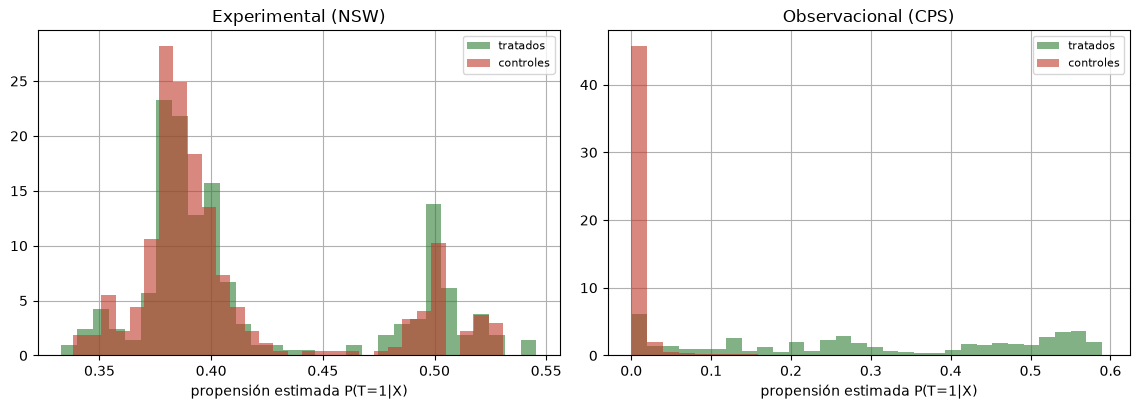

En CPS las propensiones de tratados y controles apenas se solapan: la positividad falla.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def propension(df):
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    m.fit(df[covs], df.tratamiento)
    return m.predict_proba(df[covs])[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
for a, df, titulo in [(ax[0], exp, "Experimental (NSW)"), (ax[1], cps, "Observacional (CPS)")]:
    p = propension(df)
    a.hist(p[df.tratamiento.values == 1], bins=30, alpha=.6, density=True, color="#2e7d32", label="tratados")
    a.hist(p[df.tratamiento.values == 0], bins=30, alpha=.6, density=True, color="#c0392b", label="controles")
    a.set_title(titulo); a.set_xlabel("propensión estimada P(T=1|X)"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("En CPS las propensiones de tratados y controles apenas se solapan: la positividad falla.")

## Referencias (APA 7)

- Dehejia, R. H., & Wahba, S. (1999). Causal effects in nonexperimental studies: Reevaluating the evaluation of training programs. *Journal of the American Statistical Association, 94*(448), 1053–1062.
- Holland, P. W. (1986). Statistics and causal inference. *Journal of the American Statistical Association, 81*(396), 945–960.
- Imbens, G. W., & Rubin, D. B. (2015). *Causal inference for statistics, social, and biomedical sciences: An introduction*. Cambridge University Press.
- LaLonde, R. J. (1986). Evaluating the econometric evaluations of training programs with experimental data. *American Economic Review, 76*(4), 604–620.
- Neyman, J. (1923/1990). On the application of probability theory to agricultural experiments. *Statistical Science, 5*(4), 465–472.
- Pearl, J. (2009). *Causality: Models, reasoning, and inference* (2nd ed.). Cambridge University Press.
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology, 66*(5), 688–701.